# Code 20/08

## Model
Van 1 dag 

GEOPTIMALISEERDE CASE MET VASTE KOUDE BUFFER VAN 10 M3
Koud buffer: 10.0 m3  ->  80.0 kWh
Warm buffer: 20.0 m3  ->  600.0 kWh
Warmtepomp vermogen: 500 kW
Referentie kosten: 851.35 EUR
Geoptimaliseerde kosten: 805.10 EUR
Besparing: 46.25 EUR (5.4%)
Piekbelasting: 241.55 kW


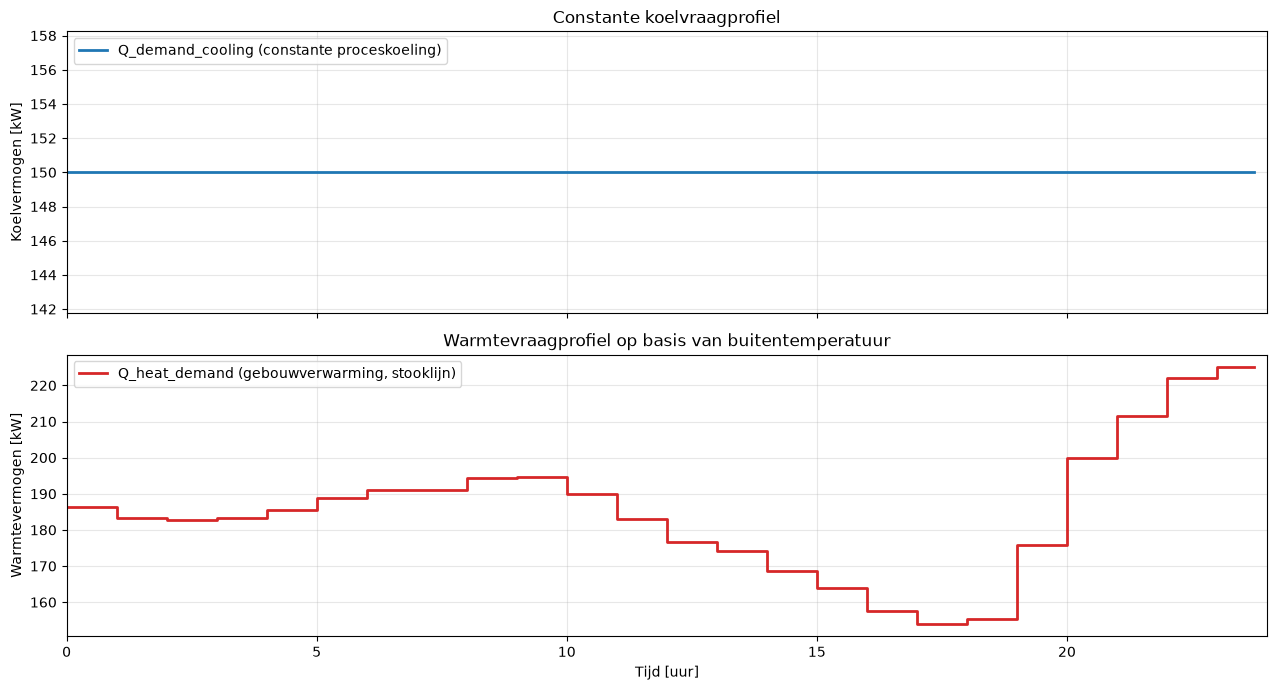

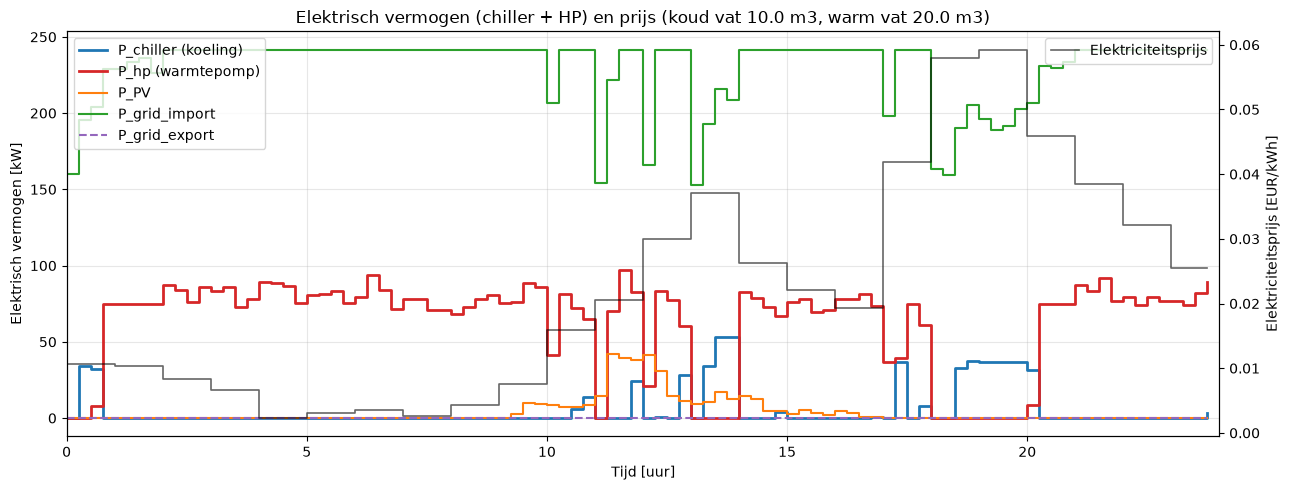

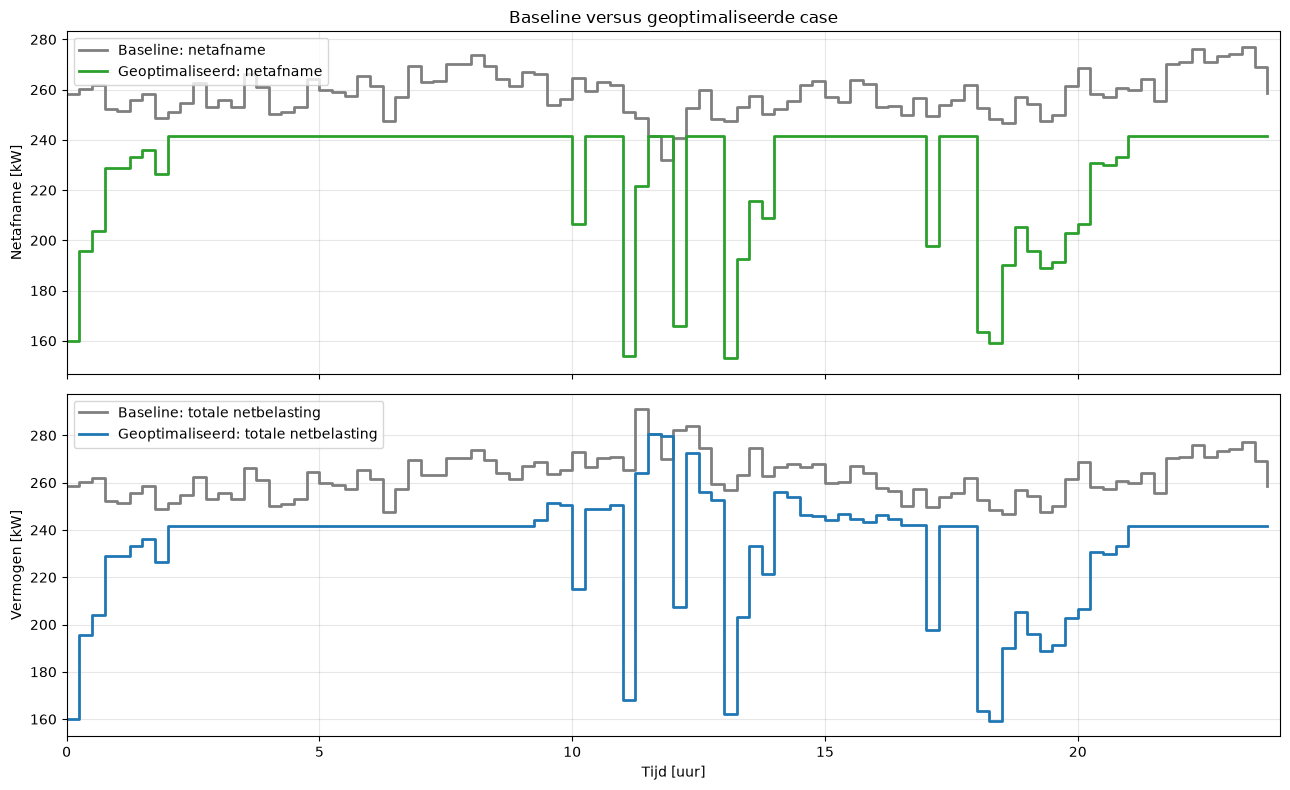

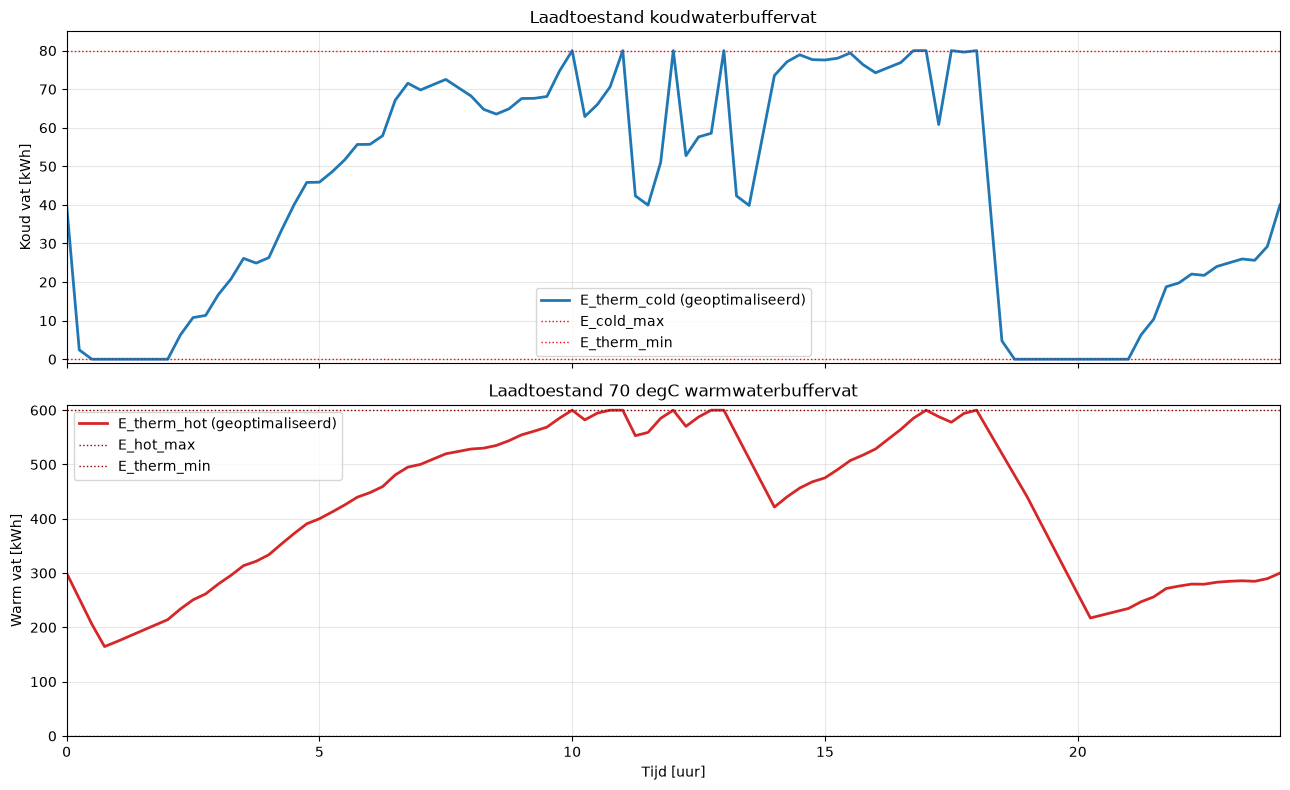

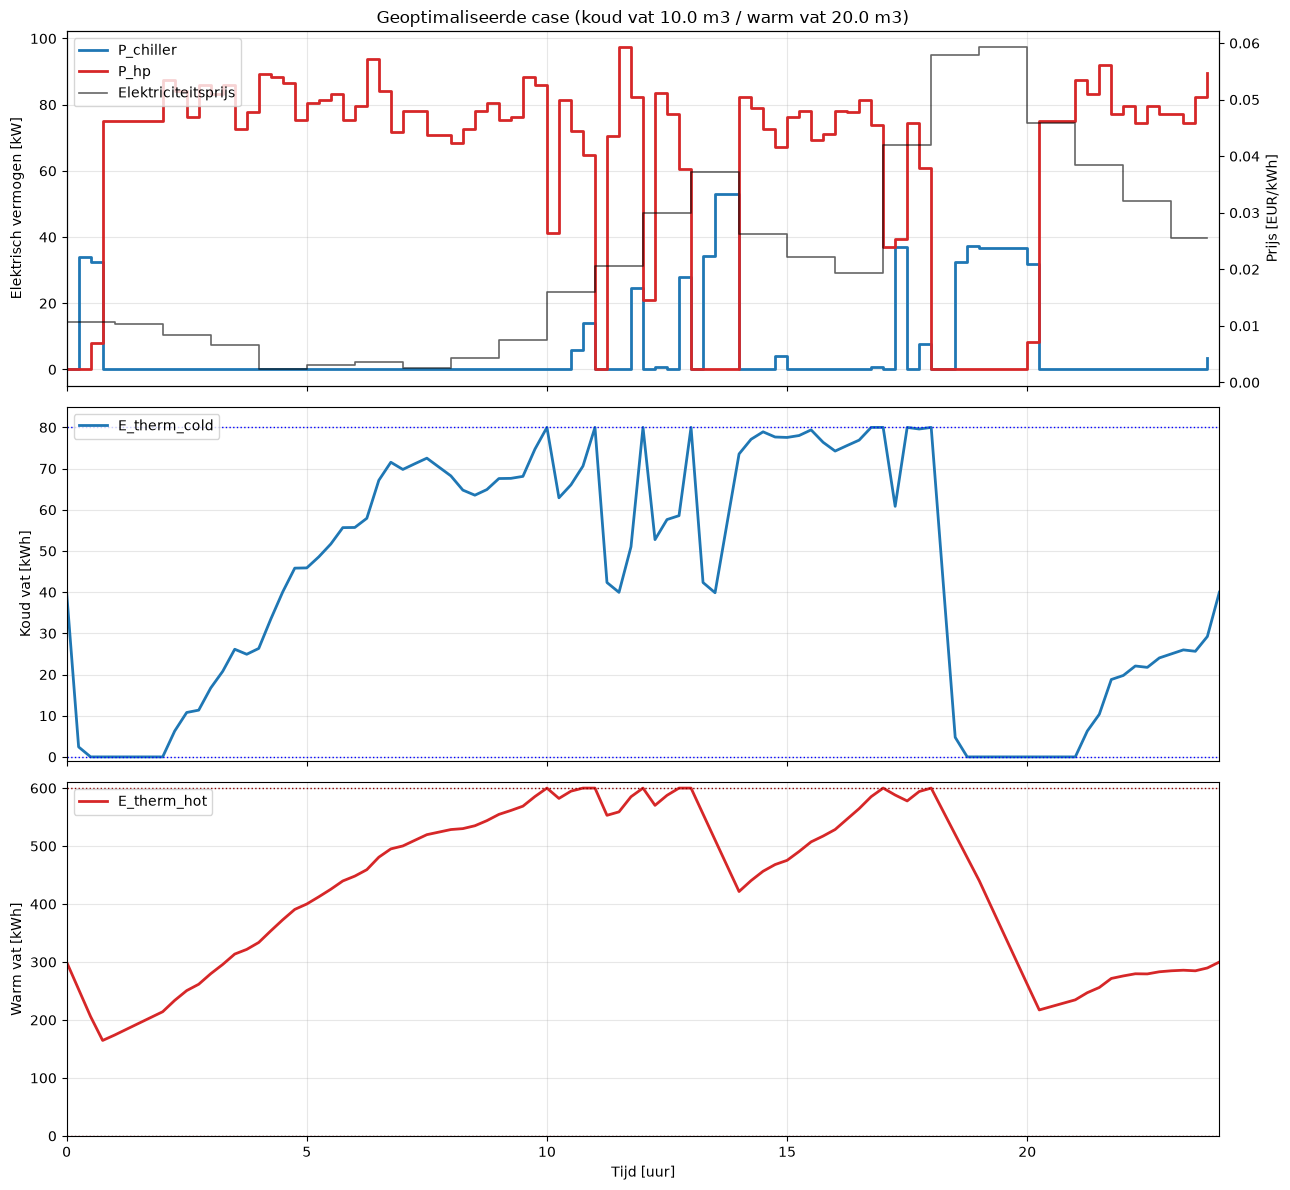


Vaste case is gevisualiseerd; geen sweep over meerdere koude-buffergroottes meer.


In [2]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_STEPS = 96  # 24 uur = 96 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)
dt = 0.25

price = df["price"].values / 1000.0
P_pv = df["pv_production"].values
P_inflex = df["inflex_load"].values
T_outdoor = df["outdoor_temperature"].values

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. VRAAGPROFIELEN
# -----------------------------------------------------------------------------
Q_process_constant = 150.0
Q_demand_cooling = np.full(N_STEPS, Q_process_constant)

Q_heat_installed_max = 300.0
T_INDOOR_SETPOINT = 20.0
T_HEATING_LIMIT = 0.0


def calculate_heat_demand(T_outdoor_array, T_indoor, T_limit, Q_max):
    frac = (T_indoor - T_outdoor_array) / (T_indoor - T_limit)
    return Q_max * np.clip(frac, 0.0, 1.0)


Q_heat_demand = calculate_heat_demand(
    T_outdoor, T_INDOOR_SETPOINT, T_HEATING_LIMIT, Q_heat_installed_max
)

# -----------------------------------------------------------------------------
# 3. PARAMETERS
# -----------------------------------------------------------------------------
P_max_chiller = 53.16
P_max_hp = 500.0

# Vast gekozen buffervatgrootte
COLD_BUFFER_M3 = 10.0
HOT_BUFFER_M3 = 20.0

# COP-curves
temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points_cooling = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points_cooling)
COP_heat_t = np.full(N_STEPS, 3.0)

# Conversie m3 -> kWh
KWH_PER_M3_COLD = 8.0
KWH_PER_M3_HOT = 30.0
E_cold_max = COLD_BUFFER_M3 * KWH_PER_M3_COLD
E_hot_max = HOT_BUFFER_M3 * KWH_PER_M3_HOT

eta_loss = 0.998
E_therm_min = 0.0

# Kostenparameters
vaste_kosten = 30.7903 / 1000.0
netverliesfactor = 0.0185
access_power = 5000.0
excess_prijs = 2.9975458 / 31.0
piekprijs = 4.2269465 / 31.0
prijs_boete = 4.4963187 / 31.0
onbalans_kost_export = 0.020


def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    if gebruik_cvxpy:
        import_kosten = cp.sum(cp.multiply(P_grid_import, price)) * dt
        export_opbrengst = (
            cp.sum(cp.multiply(P_grid_export, price - onbalans_kost_export)) * dt
        )
        spotkosten = import_kosten - export_opbrengst
        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_kosten
        )
        piek = cp.max(P_grid_import)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + cp.pos(piek - access_power) * prijs_boete
        )
    else:
        import_kosten = np.sum(P_grid_import * price) * dt
        export_opbrengst = np.sum(P_grid_export * (price - onbalans_kost_export)) * dt
        spotkosten = import_kosten - export_opbrengst
        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_kosten
        )
        piek = np.max(P_grid_import)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + max(0.0, piek - access_power) * prijs_boete
        )
    return spotkosten, energiekosten, piekkosten, piek


def solve_energy_schedule(E_cold_max, E_hot_max, P_max_hp):
    E_cold_0 = 0.5 * E_cold_max
    E_hot_0 = 0.5 * E_hot_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_hp = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm_cold = cp.Variable(N_STEPS + 1)
    E_therm_hot = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)
    Q_hot = cp.multiply(COP_heat_t, P_hp)
    Q_source = cp.multiply(COP_heat_t - 1.0, P_hp)

    constraints = [
        P_chiller <= P_max_chiller,
        P_hp <= P_max_hp,
        E_therm_cold[0] == E_cold_0,
        E_therm_cold >= E_therm_min,
        E_therm_cold <= E_cold_max,
        E_therm_cold[N_STEPS] == E_cold_0,
        E_therm_hot[0] == E_hot_0,
        E_therm_hot >= E_therm_min,
        E_therm_hot <= E_hot_max,
        E_therm_hot[N_STEPS] == E_hot_0,
        P_pv + P_grid_import == P_chiller + P_hp + P_inflex + P_grid_export,
        P_grid_export <= P_pv,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm_cold[t + 1]
            == eta_loss * E_therm_cold[t]
            + (Q_chiller[t] + Q_source[t] - Q_demand_cooling[t]) * dt,
            E_therm_hot[t + 1]
            == eta_loss * E_therm_hot[t] + (Q_hot[t] - Q_heat_demand[t]) * dt,
        ]

    spotkosten, energiekosten, piekkosten, _ = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(cp.Minimize(spotkosten + energiekosten + piekkosten), constraints)
    problem.solve(solver=cp.HIGHS)

    return {
        "cost": problem.value,
        "peak": np.max(P_grid_import.value),
        "P_chiller": P_chiller.value,
        "P_hp": P_hp.value,
        "P_grid_import": P_grid_import.value,
        "P_grid_export": P_grid_export.value,
        "E_therm_cold": E_therm_cold.value,
        "E_therm_hot": E_therm_hot.value,
    }


# -----------------------------------------------------------------------------
# 4. REFERENTIESCENARIO + GEOPTIMALISEERDE CASE MET 10 M3 KOUDE BUFFER
# -----------------------------------------------------------------------------
P_chiller_ref = np.clip(Q_demand_cooling / COP_t, 0, P_max_chiller)
P_hp_ref = np.clip(Q_heat_demand / COP_heat_t, 0, P_max_hp)

net_ref = P_chiller_ref + P_hp_ref + P_inflex - P_pv
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.minimum(np.clip(-net_ref, 0, None), P_pv)

spot_ref, ener_ref, piek_ref, _ = kosten_componenten(
    P_grid_import_ref, P_grid_export_ref, gebruik_cvxpy=False
)
cost_ref = spot_ref + ener_ref + piek_ref

opt = solve_energy_schedule(E_cold_max, E_hot_max, P_max_hp)

saving_eur = cost_ref - opt["cost"]
saving_pct = 100.0 * saving_eur / cost_ref if cost_ref != 0 else np.nan

print("=" * 80)
print("GEOPTIMALISEERDE CASE MET VASTE KOUDE BUFFER VAN 10 M3")
print("=" * 80)
print(f"Koud buffer: {COLD_BUFFER_M3:.1f} m3  ->  {E_cold_max:.1f} kWh")
print(f"Warm buffer: {HOT_BUFFER_M3:.1f} m3  ->  {E_hot_max:.1f} kWh")
print(f"Warmtepomp vermogen: {P_max_hp:.0f} kW")
print(f"Referentie kosten: {cost_ref:.2f} EUR")
print(f"Geoptimaliseerde kosten: {opt['cost']:.2f} EUR")
print(f"Besparing: {saving_eur:.2f} EUR ({saving_pct:.1f}%)")
print(f"Piekbelasting: {opt['peak']:.2f} kW")
print("=" * 80)

# -----------------------------------------------------------------------------
# 5. PLOTS VOOR DE VASTE 10 M3 CASE (geen meerdere buffergroottes)
# -----------------------------------------------------------------------------
# Grafiek 0: Vraagprofielen
fig0, (ax0a, ax0b) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax0a.step(
    time_h, Q_demand_cooling, where="post", color="tab:blue", linewidth=2,
    label="Q_demand_cooling (constante proceskoeling)",
)
ax0a.set_ylabel("Koelvermogen [kW]")
ax0a.set_title("Constante koelvraagprofiel")
ax0a.legend(loc="upper left")
ax0a.grid(alpha=0.3)

ax0b.step(
    time_h, Q_heat_demand, where="post", color="tab:red", linewidth=2,
    label="Q_heat_demand (gebouwverwarming, stooklijn)",
)
ax0b.set_xlabel("Tijd [uur]")
ax0b.set_ylabel("Warmtevermogen [kW]")
ax0b.set_xlim(0, 24)
ax0b.set_title("Warmtevraagprofiel op basis van buitentemperatuur")
ax0b.legend(loc="upper left")
ax0b.grid(alpha=0.3)
fig0.tight_layout()
plt.show()

# Grafiek 1: Elektrisch vermogen + prijs
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.step(time_h, opt["P_chiller"], where="post", label="P_chiller (koeling)",
         color="tab:blue", linewidth=2)
ax1.step(time_h, opt["P_hp"], where="post", label="P_hp (warmtepomp)",
         color="tab:red", linewidth=2)
ax1.step(time_h, P_pv, where="post", label="P_PV", color="tab:orange", linewidth=1.5)
ax1.step(time_h, opt["P_grid_import"], where="post", label="P_grid_import",
         color="tab:green", linewidth=1.5)
ax1.step(time_h, opt["P_grid_export"], where="post", label="P_grid_export",
         color="tab:purple", linewidth=1.5, linestyle="--")
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(time_h, price, where="post", color="black", linewidth=1.2, alpha=0.6,
          label="Elektriciteitsprijs")
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(f"Elektrisch vermogen (chiller + HP) en prijs (koud vat {COLD_BUFFER_M3:.1f} m3, warm vat {HOT_BUFFER_M3:.1f} m3)")
fig1.tight_layout()
plt.show()

# Grafiek 2: Baseline versus geoptimaliseerde case
baseline_total = P_chiller_ref + P_hp_ref + P_inflex
optimized_total = opt["P_chiller"] + opt["P_hp"] + P_inflex

fig_baseline, (ax_baseline_grid, ax_baseline_load) = plt.subplots(
    2, 1, figsize=(13, 8), sharex=True
)
ax_baseline_grid.step(
    time_h, P_grid_import_ref, where="post", linewidth=2,
    label="Baseline: netafname", color="tab:gray",
)
ax_baseline_grid.step(
    time_h, opt["P_grid_import"], where="post", linewidth=2,
    label="Geoptimaliseerd: netafname", color="tab:green",
)
ax_baseline_grid.set_ylabel("Netafname [kW]")
ax_baseline_grid.set_title("Baseline versus geoptimaliseerde case")
ax_baseline_grid.grid(alpha=0.3)
ax_baseline_grid.legend(loc="upper left")

ax_baseline_load.step(
    time_h, baseline_total, where="post", linewidth=2,
    label="Baseline: totale netbelasting", color="tab:gray",
)
ax_baseline_load.step(
    time_h, optimized_total, where="post", linewidth=2,
    label="Geoptimaliseerd: totale netbelasting", color="tab:blue",
)
ax_baseline_load.set_xlabel("Tijd [uur]")
ax_baseline_load.set_ylabel("Vermogen [kW]")
ax_baseline_load.set_xlim(0, 24)
ax_baseline_load.grid(alpha=0.3)
ax_baseline_load.legend(loc="upper left")
fig_baseline.tight_layout()
plt.show()

# Grafiek 3: Buffervatlaadtoestand
fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
time_h_full = np.arange(N_STEPS + 1) * dt

ax2a.plot(time_h_full, opt["E_therm_cold"],
          label="E_therm_cold (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax2a.axhline(E_cold_max, color="red", linestyle=":", linewidth=1, label="E_cold_max")
ax2a.axhline(E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min")
ax2a.set_ylabel("Koud vat [kWh]")
ax2a.set_ylim(-1, E_cold_max + 5)
ax2a.grid(alpha=0.3)
ax2a.legend(loc="best")
ax2a.set_title("Laadtoestand koudwaterbuffervat")

ax2b.plot(time_h_full, opt["E_therm_hot"],
          label="E_therm_hot (geoptimaliseerd)", color="tab:red", linewidth=2)
ax2b.axhline(E_hot_max, color="darkred", linestyle=":", linewidth=1, label="E_hot_max")
ax2b.axhline(E_therm_min, color="darkred", linestyle=":", linewidth=1, label="E_therm_min")
ax2b.set_xlabel("Tijd [uur]")
ax2b.set_ylabel("Warm vat [kWh]")
ax2b.set_xlim(0, 24)
ax2b.set_ylim(-1, E_hot_max + 10)
ax2b.grid(alpha=0.3)
ax2b.legend(loc="best")
ax2b.set_title("Laadtoestand 70 degC warmwaterbuffervat")
fig2.tight_layout()
plt.show()

# Grafiek 4: Gecombineerde statusplot van vermogen, buffers en prijs
fig3, (ax_top, ax_mid, ax_bottom) = plt.subplots(nrows=3, ncols=1, figsize=(13, 12), sharex=True)

ax_top.step(time_h, opt["P_chiller"], where="post", label="P_chiller", color="tab:blue", linewidth=2)
ax_top.step(time_h, opt["P_hp"], where="post", label="P_hp", color="tab:red", linewidth=2)
ax_top.set_ylabel("Elektrisch vermogen [kW]")
ax_top.set_xlim(0, 24)
ax_top.grid(alpha=0.3)

ax_top_price = ax_top.twinx()
ax_top_price.step(time_h, price, where="post", color="black", linewidth=1.2, alpha=0.6,
                 label="Elektriciteitsprijs")
ax_top_price.set_ylabel("Prijs [EUR/kWh]", color="black")
ax_top_price.tick_params(axis="y", labelcolor="black")

lines_top, labels_top = ax_top.get_legend_handles_labels()
lines_price, labels_price = ax_top_price.get_legend_handles_labels()
ax_top.legend(lines_top + lines_price, labels_top + labels_price, loc="upper left")
ax_top.set_title(f"Geoptimaliseerde case (koud vat {COLD_BUFFER_M3:.1f} m3 / warm vat {HOT_BUFFER_M3:.1f} m3)")

ax_mid.plot(time_h_full, opt["E_therm_cold"],
            label="E_therm_cold", color="tab:blue", linewidth=2)
ax_mid.axhline(E_cold_max, color="blue", linestyle=":", linewidth=1)
ax_mid.axhline(E_therm_min, color="blue", linestyle=":", linewidth=1)
ax_mid.set_ylabel("Koud vat [kWh]")
ax_mid.set_ylim(-1, E_cold_max + 5)
ax_mid.grid(alpha=0.3)
ax_mid.legend(loc="upper left")

ax_bottom.plot(time_h_full, opt["E_therm_hot"],
               label="E_therm_hot", color="tab:red", linewidth=2)
ax_bottom.axhline(E_hot_max, color="darkred", linestyle=":", linewidth=1)
ax_bottom.axhline(E_therm_min, color="darkred", linestyle=":", linewidth=1)
ax_bottom.set_xlabel("Tijd [uur]")
ax_bottom.set_ylabel("Warm vat [kWh]")
ax_bottom.set_xlim(0, 24)
ax_bottom.set_ylim(-1, E_hot_max + 10)
ax_bottom.grid(alpha=0.3)
ax_bottom.legend(loc="upper left")

fig3.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. SLOT: samenvatting voor de vaste case
# -----------------------------------------------------------------------------
print("\nVaste case is gevisualiseerd; geen sweep over meerdere koude-buffergroottes meer.")


## NPV met verschillende grotes

In [4]:
import cvxpy as cp
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_STEPS = 96

df = df.iloc[:N_STEPS].reset_index(drop=True)
dt = 0.25

price = df["price"].values / 1000.0
P_pv = df["pv_production"].values
P_inflex = df["inflex_load"].values
T_outdoor = df["outdoor_temperature"].values

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. VRAAGPROFIELEN
# -----------------------------------------------------------------------------
Q_process_constant = 150.0
Q_demand_cooling = np.full(N_STEPS, Q_process_constant)

Q_heat_installed_max = 300.0
T_INDOOR_SETPOINT = 20.0
T_HEATING_LIMIT = 0.0


def calculate_heat_demand(T_outdoor_array, T_indoor, T_limit, Q_max):
    frac = (T_indoor - T_outdoor_array) / (T_indoor - T_limit)
    return Q_max * np.clip(frac, 0.0, 1.0)


Q_heat_demand = calculate_heat_demand(
    T_outdoor, T_INDOOR_SETPOINT, T_HEATING_LIMIT, Q_heat_installed_max
)

# -----------------------------------------------------------------------------
# 3. PARAMETERS
# -----------------------------------------------------------------------------
P_max_chiller = 53.16
P_max_hp = 500.0

COLD_BUFFER_M3 = 10.0
HOT_BUFFER_M3 = 20.0

# COP-curves
temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points_cooling = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points_cooling)
COP_heat_t = np.full(N_STEPS, 3.0)

KWH_PER_M3_COLD = 8.0
KWH_PER_M3_HOT = 30.0
E_cold_max = COLD_BUFFER_M3 * KWH_PER_M3_COLD
E_hot_max = HOT_BUFFER_M3 * KWH_PER_M3_HOT

eta_loss = 0.998
E_therm_min = 0.0

# Kostenparameters
vaste_kosten = 30.7903 / 1000.0
netverliesfactor = 0.0185
access_power = 5000.0
excess_prijs = 2.9975458 / 31.0
piekprijs = 4.2269465 / 31.0
prijs_boete = 4.4963187 / 31.0
onbalans_kost_export = 0.020


def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    if gebruik_cvxpy:
        import_kosten = cp.sum(cp.multiply(P_grid_import, price)) * dt
        export_opbrengst = (
            cp.sum(cp.multiply(P_grid_export, price - onbalans_kost_export)) * dt
        )
        spotkosten = import_kosten - export_opbrengst
        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_kosten
        )
        piek = cp.max(P_grid_import)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + cp.pos(piek - access_power) * prijs_boete
        )
    else:
        import_kosten = np.sum(P_grid_import * price) * dt
        export_opbrengst = np.sum(P_grid_export * (price - onbalans_kost_export)) * dt
        spotkosten = import_kosten - export_opbrengst
        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_kosten
        )
        piek = np.max(P_grid_import)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + max(0.0, piek - access_power) * prijs_boete
        )
    return spotkosten, energiekosten, piekkosten, piek


def solve_energy_schedule(E_cold_max, E_hot_max, P_max_hp):
    E_cold_0 = 0.5 * E_cold_max
    E_hot_0 = 0.5 * E_hot_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_hp = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm_cold = cp.Variable(N_STEPS + 1)
    E_therm_hot = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)
    Q_hot = cp.multiply(COP_heat_t, P_hp)
    Q_source = cp.multiply(COP_heat_t - 1.0, P_hp)

    constraints = [
        P_chiller <= P_max_chiller,
        P_hp <= P_max_hp,
        E_therm_cold[0] == E_cold_0,
        E_therm_cold >= E_therm_min,
        E_therm_cold <= E_cold_max,
        E_therm_cold[N_STEPS] == E_cold_0,
        E_therm_hot[0] == E_hot_0,
        E_therm_hot >= E_therm_min,
        E_therm_hot <= E_hot_max,
        E_therm_hot[N_STEPS] == E_hot_0,
        P_pv + P_grid_import == P_chiller + P_hp + P_inflex + P_grid_export,
        P_grid_export <= P_pv,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm_cold[t + 1]
            == eta_loss * E_therm_cold[t]
            + (Q_chiller[t] + Q_source[t] - Q_demand_cooling[t]) * dt,
            E_therm_hot[t + 1]
            == eta_loss * E_therm_hot[t] + (Q_hot[t] - Q_heat_demand[t]) * dt,
        ]

    spotkosten, energiekosten, piekkosten, _ = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(cp.Minimize(spotkosten + energiekosten + piekkosten), constraints)
    problem.solve(solver=cp.HIGHS)

    return {
        "cost": problem.value,
        "peak": np.max(P_grid_import.value),
        "P_chiller": P_chiller.value,
        "P_hp": P_hp.value,
        "P_grid_import": P_grid_import.value,
        "P_grid_export": P_grid_export.value,
        "E_therm_cold": E_therm_cold.value,
        "E_therm_hot": E_therm_hot.value,
    }


# -----------------------------------------------------------------------------
# 4. REFERENTIESCENARIO + GEOPTIMALISEERDE CASE MET 10 M3 KOUDE BUFFER
# -----------------------------------------------------------------------------
P_chiller_ref = np.clip(Q_demand_cooling / COP_t, 0, P_max_chiller)
P_hp_ref = np.clip(Q_heat_demand / COP_heat_t, 0, P_max_hp)

net_ref = P_chiller_ref + P_hp_ref + P_inflex - P_pv
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.minimum(np.clip(-net_ref, 0, None), P_pv)

spot_ref, ener_ref, piek_ref, _ = kosten_componenten(
    P_grid_import_ref, P_grid_export_ref, gebruik_cvxpy=False
)
cost_ref = spot_ref + ener_ref + piek_ref

opt = solve_energy_schedule(E_cold_max, E_hot_max, P_max_hp)

saving_eur = cost_ref - opt["cost"]
saving_pct = 100.0 * saving_eur / cost_ref if cost_ref != 0 else np.nan

print("=" * 80)
print("GEOPTIMALISEERDE CASE MET VASTE KOUDE BUFFER VAN 10 M3")
print("=" * 80)
print(f"Koud buffer: {COLD_BUFFER_M3:.1f} m3  ->  {E_cold_max:.1f} kWh")
print(f"Warm buffer: {HOT_BUFFER_M3:.1f} m3  ->  {E_hot_max:.1f} kWh")
print(f"Warmtepomp vermogen: {P_max_hp:.0f} kW")
print(f"Referentie kosten: {cost_ref:.2f} EUR")
print(f"Geoptimaliseerde kosten: {opt['cost']:.2f} EUR")
print(f"Besparing: {saving_eur:.2f} EUR ({saving_pct:.1f}%)")
print(f"Piekbelasting: {opt['peak']:.2f} kW")
print("=" * 80)


GEOPTIMALISEERDE CASE MET VASTE KOUDE BUFFER VAN 10 M3
Koud buffer: 10.0 m3  ->  80.0 kWh
Warm buffer: 20.0 m3  ->  600.0 kWh
Warmtepomp vermogen: 500 kW
Referentie kosten: 851.35 EUR
Geoptimaliseerde kosten: 805.10 EUR
Besparing: 46.25 EUR (5.4%)
Piekbelasting: 241.55 kW


# Scenarioanalyse

Start parameter sweep (dit kan even duren afhankelijk van grid-grootte)...
Voortgang: 20/330 combinaties berekend...
Voortgang: 40/330 combinaties berekend...
Voortgang: 60/330 combinaties berekend...
Voortgang: 80/330 combinaties berekend...
Voortgang: 100/330 combinaties berekend...
Voortgang: 120/330 combinaties berekend...
Voortgang: 140/330 combinaties berekend...
Voortgang: 160/330 combinaties berekend...
Voortgang: 180/330 combinaties berekend...
Voortgang: 200/330 combinaties berekend...
Voortgang: 220/330 combinaties berekend...
Voortgang: 240/330 combinaties berekend...
Voortgang: 260/330 combinaties berekend...
Voortgang: 280/330 combinaties berekend...
Voortgang: 300/330 combinaties berekend...
Voortgang: 320/330 combinaties berekend...
Voortgang: 330/330 combinaties berekend...

BEST PRESTERENDE CONFIGURATIE (Hoogste NPV)
Koude Buffer:       5.0 m³
Warme Buffer:       10.0 m³
Warmtepomp:         250 kW
Totale CAPEX:       € 82,500.00
Jaarlijkse besparing: € 16,531.88
Net P

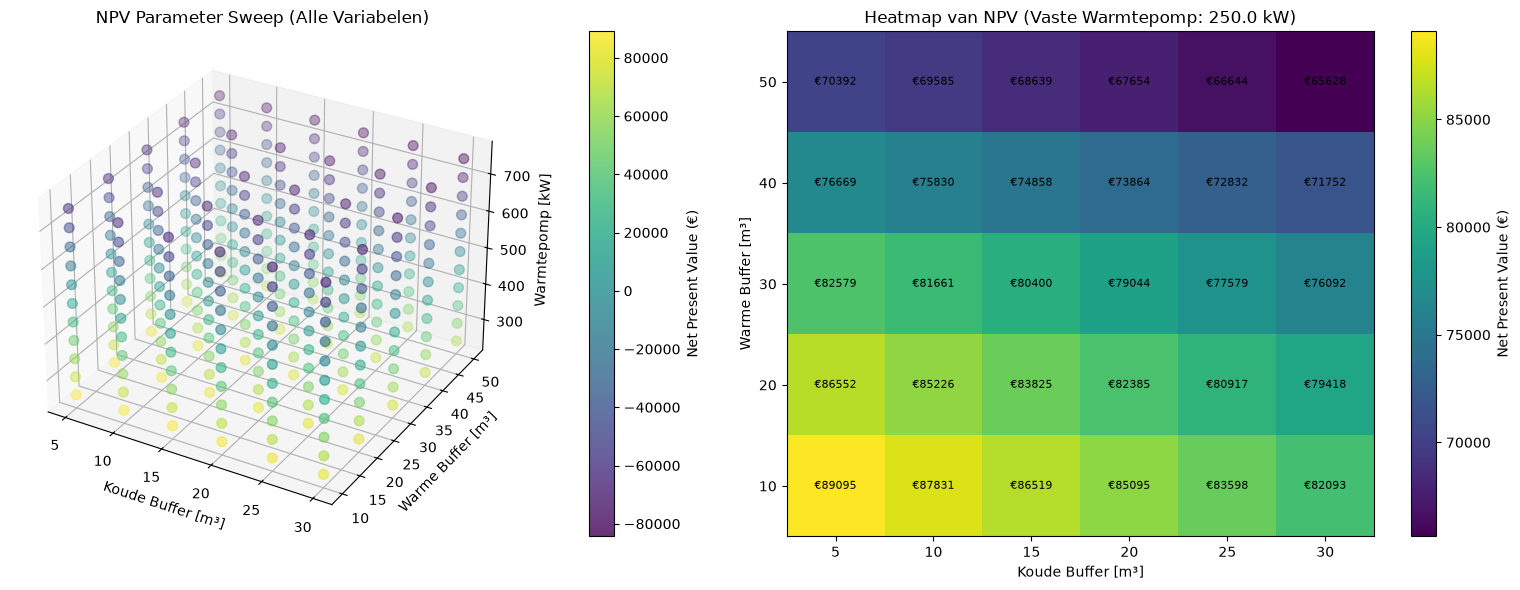

In [5]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_STEPS = 96  # 24 uur = 96 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)
dt = 0.25

price = df["price"].values / 1000.0
P_pv = df["pv_production"].values
P_inflex = df["inflex_load"].values
T_outdoor = df["outdoor_temperature"].values

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. VRAAGPROFIELEN
# -----------------------------------------------------------------------------
Q_process_constant = 150.0
Q_demand_cooling = np.full(N_STEPS, Q_process_constant)

Q_heat_installed_max = 300.0
T_INDOOR_SETPOINT = 20.0
T_HEATING_LIMIT = 0.0

def calculate_heat_demand(T_outdoor_array, T_indoor, T_limit, Q_max):
    frac = (T_indoor - T_outdoor_array) / (T_indoor - T_limit)
    return Q_max * np.clip(frac, 0.0, 1.0)

Q_heat_demand = calculate_heat_demand(
    T_outdoor, T_INDOOR_SETPOINT, T_HEATING_LIMIT, Q_heat_installed_max
)

# -----------------------------------------------------------------------------
# 3. VASTE PARAMETERS & KOSTENFUNCTIE
# -----------------------------------------------------------------------------
P_max_chiller = 53.16

# COP-curves
temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points_cooling = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points_cooling)
COP_heat_t = np.full(N_STEPS, 3.0)

# Conversie m3 -> kWh
KWH_PER_M3_COLD = 8.0
KWH_PER_M3_HOT = 30.0

eta_loss = 0.998
E_therm_min = 0.0

# Netkostenparameters
vaste_kosten = 30.7903 / 1000.0
netverliesfactor = 0.0185
access_power = 5000.0
excess_prijs = 2.9975458 / 31.0
piekprijs = 4.2269465 / 31.0
prijs_boete = 4.4963187 / 31.0
onbalans_kost_export = 0.020

def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    if gebruik_cvxpy:
        import_kosten = cp.sum(cp.multiply(P_grid_import, price)) * dt
        export_opbrengst = (
            cp.sum(cp.multiply(P_grid_export, price - onbalans_kost_export)) * dt
        )
        spotkosten = import_kosten - export_opbrengst
        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_kosten
        )
        piek = cp.max(P_grid_import)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + cp.pos(piek - access_power) * prijs_boete
        )
    else:
        import_kosten = np.sum(P_grid_import * price) * dt
        export_opbrengst = np.sum(P_grid_export * (price - onbalans_kost_export)) * dt
        spotkosten = import_kosten - export_opbrengst
        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_kosten
        )
        piek = np.max(P_grid_import)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + max(0.0, piek - access_power) * prijs_boete
        )
    return spotkosten, energiekosten, piekkosten, piek

def solve_energy_schedule(E_cold_max, E_hot_max, P_max_hp):
    E_cold_0 = 0.5 * E_cold_max
    E_hot_0 = 0.5 * E_hot_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_hp = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm_cold = cp.Variable(N_STEPS + 1)
    E_therm_hot = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)
    Q_hot = cp.multiply(COP_heat_t, P_hp)
    Q_source = cp.multiply(COP_heat_t - 1.0, P_hp)

    constraints = [
        P_chiller <= P_max_chiller,
        P_hp <= P_max_hp,
        E_therm_cold[0] == E_cold_0,
        E_therm_cold >= E_therm_min,
        E_therm_cold <= E_cold_max,
        E_therm_cold[N_STEPS] == E_cold_0,
        E_therm_hot[0] == E_hot_0,
        E_therm_hot >= E_therm_min,
        E_therm_hot <= E_hot_max,
        E_therm_hot[N_STEPS] == E_hot_0,
        P_pv + P_grid_import == P_chiller + P_hp + P_inflex + P_grid_export,
        P_grid_export <= P_pv,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm_cold[t + 1]
            == eta_loss * E_therm_cold[t]
            + (Q_chiller[t] + Q_source[t] - Q_demand_cooling[t]) * dt,
            E_therm_hot[t + 1]
            == eta_loss * E_therm_hot[t] + (Q_hot[t] - Q_heat_demand[t]) * dt,
        ]

    spotkosten, energiekosten, piekkosten, _ = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(cp.Minimize(spotkosten + energiekosten + piekkosten), constraints)
    problem.solve(solver=cp.HIGHS)

    return problem.value

def calc_reference_cost(P_max_hp):
    """Berekent de kosten voor een standaard setup zonder slimme buffers"""
    P_chiller_ref = np.clip(Q_demand_cooling / COP_t, 0, P_max_chiller)
    P_hp_ref = np.clip(Q_heat_demand / COP_heat_t, 0, P_max_hp)

    net_ref = P_chiller_ref + P_hp_ref + P_inflex - P_pv
    P_grid_import_ref = np.clip(net_ref, 0, None)
    P_grid_export_ref = np.minimum(np.clip(-net_ref, 0, None), P_pv)

    spot_ref, ener_ref, piek_ref, _ = kosten_componenten(
        P_grid_import_ref, P_grid_export_ref, gebruik_cvxpy=False
    )
    return spot_ref + ener_ref + piek_ref

# -----------------------------------------------------------------------------
# 4. PARAMETER SWEEP EN ECONOMISCHE ANALYSE (NPV)
# -----------------------------------------------------------------------------
print("Start parameter sweep (dit kan even duren afhankelijk van grid-grootte)...")

# Definieer ranges (pas deze naar wens aan)
cold_buffer_range = np.arange(5, 35, 5)   # 5 tot 30 in stappen van 5
hot_buffer_range = np.arange(10, 60, 10)  # 10 tot 50 in stappen van 10
p_max_hp_range = np.arange(250, 800, 50)  # 250 tot 750 in stappen van 50

# Economische aannames
PROJECT_LIFESPAN = 15      # in jaren
DISCOUNT_RATE = 0.05       # 5% disconteringsvoet
CAPEX_BUFFER_M3 = 500.0    # € per m³ buffervat
CAPEX_HP_KW = 300.0        # € per kW warmtepomp

# Bereken de annuïteitsfactor voor NPV
annuity_factor = (1 - (1 + DISCOUNT_RATE)**-PROJECT_LIFESPAN) / DISCOUNT_RATE

results = []
total_iterations = len(cold_buffer_range) * len(hot_buffer_range) * len(p_max_hp_range)
count = 0

# Itereren over alle mogelijke combinaties
for c_vol, h_vol, p_max in itertools.product(cold_buffer_range, hot_buffer_range, p_max_hp_range):
    E_cold_max = c_vol * KWH_PER_M3_COLD
    E_hot_max = h_vol * KWH_PER_M3_HOT

    # 1. Operationele kosten (Optimized & Referentie)
    cost_opt = solve_energy_schedule(E_cold_max, E_hot_max, p_max)
    cost_ref = calc_reference_cost(p_max)
    
    saving_eur_day = cost_ref - cost_opt
    saving_eur_year = saving_eur_day * 365
    
    # 2. Investeringskosten (CAPEX)
    capex = (c_vol + h_vol) * CAPEX_BUFFER_M3 + p_max * CAPEX_HP_KW
    
    # 3. Net Present Value (NPV)
    # Formule: Huidige waarde van alle jaarlijkse besparingen - CAPEX
    npv = (saving_eur_year * annuity_factor) - capex
    
    results.append({
        "Cold_Buffer_m3": c_vol,
        "Hot_Buffer_m3": h_vol,
        "HP_Capacity_kW": p_max,
        "CAPEX_EUR": capex,
        "Daily_Saving_EUR": saving_eur_day,
        "Yearly_Saving_EUR": saving_eur_year,
        "NPV_EUR": npv,
        "Opt_Cost_Day_EUR": cost_opt,
        "Ref_Cost_Day_EUR": cost_ref
    })

    count += 1
    if count % 20 == 0 or count == total_iterations:
        print(f"Voortgang: {count}/{total_iterations} combinaties berekend...")

df_results = pd.DataFrame(results)

# -----------------------------------------------------------------------------
# 5. OUTPUT EN RESULTATEN
# -----------------------------------------------------------------------------
best_setup = df_results.loc[df_results['NPV_EUR'].idxmax()]

print("\n" + "=" * 80)
print("BEST PRESTERENDE CONFIGURATIE (Hoogste NPV)")
print("=" * 80)
print(f"Koude Buffer:       {best_setup['Cold_Buffer_m3']:.1f} m³")
print(f"Warme Buffer:       {best_setup['Hot_Buffer_m3']:.1f} m³")
print(f"Warmtepomp:         {best_setup['HP_Capacity_kW']:.0f} kW")
print(f"Totale CAPEX:       € {best_setup['CAPEX_EUR']:,.2f}")
print(f"Jaarlijkse besparing: € {best_setup['Yearly_Saving_EUR']:,.2f}")
print(f"Net Present Value:  € {best_setup['NPV_EUR']:,.2f}")
print("=" * 80)

# -----------------------------------------------------------------------------
# 6. PLOTS: 3D-GRAFIEK & HEATMAP
# -----------------------------------------------------------------------------
best_hp = best_setup['HP_Capacity_kW']

fig = plt.figure(figsize=(16, 6))

# Plot 1: 3D Scatter Plot (Alle combinaties)
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(
    df_results['Cold_Buffer_m3'], 
    df_results['Hot_Buffer_m3'], 
    df_results['HP_Capacity_kW'],
    c=df_results['NPV_EUR'], cmap='viridis', s=50, alpha=0.8
)
cbar = plt.colorbar(sc1, ax=ax1, pad=0.1)
cbar.set_label('Net Present Value (€)')
ax1.set_xlabel('Koude Buffer [m³]')
ax1.set_ylabel('Warme Buffer [m³]')
ax1.set_zlabel('Warmtepomp [kW]')
ax1.set_title('NPV Parameter Sweep (Alle Variabelen)')

# Plot 2: Heatmap (NPV voor de optimale Warmtepomp capaciteit)
ax2 = fig.add_subplot(122)
df_heatmap = df_results[df_results['HP_Capacity_kW'] == best_hp].copy()
pivot_table = df_heatmap.pivot(index='Hot_Buffer_m3', columns='Cold_Buffer_m3', values='NPV_EUR')

cax = ax2.imshow(pivot_table, cmap='viridis', origin='lower', aspect='auto')
cbar2 = plt.colorbar(cax, ax=ax2)
cbar2.set_label('Net Present Value (€)')

ax2.set_xticks(np.arange(len(pivot_table.columns)))
ax2.set_yticks(np.arange(len(pivot_table.index)))
ax2.set_xticklabels(pivot_table.columns)
ax2.set_yticklabels(pivot_table.index)
ax2.set_xlabel('Koude Buffer [m³]')
ax2.set_ylabel('Warme Buffer [m³]')
ax2.set_title(f'Heatmap van NPV (Vaste Warmtepomp: {best_hp} kW)')

# Waarden toevoegen in de blokken van de heatmap
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        val = pivot_table.iloc[i, j]
        ax2.text(j, i, f"€{int(val)}", ha="center", va="center", color="white" if val < pivot_table.values.max() * 0.7 else "black", fontsize=8)

plt.tight_layout()
plt.show()